Day 12: Logistic Regression & Classification Metrics.

In [3]:
from sklearn.datasets import load_breast_cancer

In [7]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2,
random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_prob = model.predict_proba(X_test_scaled)

print(y_prob[:5])

[[1.13590250e-01 8.86409750e-01]
 [9.99990991e-01 9.00936206e-06]
 [9.96920905e-01 3.07909541e-03]
 [5.10134225e-04 9.99489866e-01]
 [6.06389713e-05 9.99939361e-01]]


In [8]:
y_pred = model.predict(X_test_scaled)

print("Predictions:", y_pred[:5])
print("Probabilities:\n", y_prob[:5])

Predictions: [1 0 0 1 1]
Probabilities:
 [[1.13590250e-01 8.86409750e-01]
 [9.99990991e-01 9.00936206e-06]
 [9.96920905e-01 3.07909541e-03]
 [5.10134225e-04 9.99489866e-01]
 [6.06389713e-05 9.99939361e-01]]


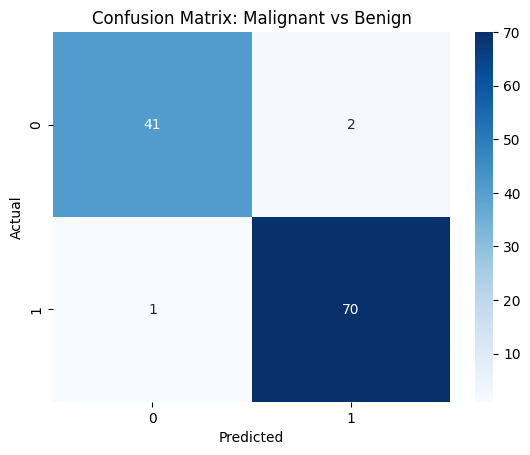

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Malignant vs Benign')
plt.show()

In a medical scenario like cancer detection, which is worse: a False Positive (telling a healthy person they are sick) or a False Negative (telling a sick person they are healthy)? Why?

A False Negative is worse.

If someone who has cancer is told they are healthy, they won’t get treatment, and the disease can become more serious. 
A False Positive may cause worry, but it can be checked and corrected.